# 03 — Mendeley EU cartel dataset EDA (D4, primary labeled procurement anchor)

Week-1 goals (§7 step 3, §4.3 D4): **measure** cartel prevalence and cartel-case counts (problem statement says 73 cases / 15,000+ cartel contracts — to be confirmed, not assumed), and **map losing-bidder coverage by country-year** — this drives the §4.2 co-bid enrichment tier.

File: `GTI_labelled_cartel_data_NOV2023.csv` (Fazekas, Wachs, Tóth & Abdou; CC BY NC 3.0).

In [1]:
import polars as pl

RESULTS = []

def check(name, expected, actual):
    """Soft verification: record PASS/FAIL, never crash mid-notebook."""
    ok = expected == actual
    RESULTS.append((name, expected, actual, ok))
    print(f"{'PASS' if ok else 'FAIL'}  {name}: expected={expected!r} actual={actual!r}")
    return ok

def summary():
    print("\n=== VERIFICATION SUMMARY ===")
    for name, exp, act, ok in RESULTS:
        print(f"{'PASS' if ok else 'FAIL'}  {name}: expected={exp!r} actual={act!r}")
    n_fail = sum(1 for r in RESULTS if not r[3])
    print(f"{len(RESULTS) - n_fail}/{len(RESULTS)} checks passed")


In [2]:
DATA = "../data/raw/mendeley_eu"
df = pl.read_csv(f"{DATA}/GTI_labelled_cartel_data_NOV2023.csv",
                 infer_schema_length=20000, ignore_errors=True)
print(df.shape)
print(df.columns)
df.head(5)

(15616, 34)
['persistent_id', 'tender_id', 'lot_id', 'country', 'tender_year', 'buyer_id', 'bidder_id', 'is_cartel', 'cartel_tender', 'lot_bidscount', 'lot_bidscount_avg', 'lot_bidscount_avg_lag', 'singleb_avg', 'singleb_avg_lag', 'bid_isconsortium', 'bid_issubcontracted', 'bid_issubcontracted_avg', 'bid_issubcontracted_avg_lag', 'relative_value', 'relative_value_avg', 'relative_value_avg_lag', 'cpv3_avg_bidder_yearly', 'cpv3_avg_bidder_yearly_avg_lag', 'buyer_avg_bidder_yearly', 'buyer_avg_bidder_yearly_avg_lag', 'contract_count_bidder_yearly', 'MAD_buyer', 'benfords_buyer_yearly_avg', 'benfords_buyer_yearly_avg_lag', 'MAD_market', 'benfords_market_yearly_avg', 'benfords_market_yearly_avg_lag', 'cpv2_smp', 'cartel_id']


persistent_id,tender_id,lot_id,country,tender_year,buyer_id,bidder_id,is_cartel,cartel_tender,lot_bidscount,lot_bidscount_avg,lot_bidscount_avg_lag,singleb_avg,singleb_avg_lag,bid_isconsortium,bid_issubcontracted,bid_issubcontracted_avg,bid_issubcontracted_avg_lag,relative_value,relative_value_avg,relative_value_avg_lag,cpv3_avg_bidder_yearly,cpv3_avg_bidder_yearly_avg_lag,buyer_avg_bidder_yearly,buyer_avg_bidder_yearly_avg_lag,contract_count_bidder_yearly,MAD_buyer,benfords_buyer_yearly_avg,benfords_buyer_yearly_avg_lag,MAD_market,benfords_market_yearly_avg,benfords_market_yearly_avg_lag,cpv2_smp,cartel_id
str,str,str,str,i64,str,str,i64,i64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,str,str
"""BG_29ce5dbd3a68720d7c8c685774d…","""03f10e1f-2f8a-4f07-84b1-43c835…","""group_BG_tender_0179f9f8953e73…","""country_1""",2021,"""country_1_2135""","""country_1_19""",0,45,3.0,2.3,2.833333,0.1,0.5,0,9,0.092301,0.0,0.585034,0.564484,0.829914,0.047619,0.666667,0.190476,0.833333,21,0.022694,0.022694,0.032046,0.018282,0.018282,0.022488,"""23""","""country_1_5"""
"""BG_b3fb8c346521b63ae1ae668e232…","""3294565b-294c-4b14-b77a-00df7d…","""group_BG_tender_02abd880ff514b…","""country_1""",2020,"""country_1_2094""","""country_1_29""",0,68,6.0,6.638347,7.732211,0.249386,0.247704,0,9,0.092301,0.09938,0.917819,0.905942,0.906711,1.0,0.275407,1.0,0.605411,1,0.031405,0.031031,0.032046,0.019854,0.020128,0.020953,"""23""","""country_1_5"""
"""BG_8aa9d9fb0d6452ca7e2aadf00d2…","""4635325e-9d00-43ea-8cc1-4970ac…","""group_BG_tender_02b51ce736dad4…","""country_1""",2020,"""country_1_2094""","""country_1_8""",0,19,3.0,6.638347,7.732211,0.249386,0.247704,0,9,0.092301,0.09938,0.96,0.905942,0.906711,0.5,0.275407,0.5,0.605411,2,0.031405,0.031031,0.032046,0.019854,0.020128,0.020953,"""23""","""country_1_5"""
"""BG_8aa9d9fb0d6452ca7e2aadf00d2…","""4635325e-9d00-43ea-8cc1-4970ac…","""group_BG_tender_02b51ce736dad4…","""country_1""",2020,"""country_1_2094""","""country_1_8""",0,19,3.0,6.638347,7.732211,0.249386,0.247704,0,9,0.092301,0.09938,0.97,0.905942,0.906711,0.5,0.275407,0.5,0.605411,2,0.031405,0.031031,0.032046,0.019854,0.020128,0.020953,"""23""","""country_1_5"""
"""BG_261fe2e93ed0dffcd515bba1e69…","""82473b6e-c3af-4f4b-8a74-04eecd…","""group_BG_tender_0487dfc02dd2b6…","""country_1""",2012,"""country_1_2144""","""country_1_13""",1,29,3.0,6.638347,7.732211,0.249386,0.247704,0,0,0.092301,0.09938,0.917819,0.905942,0.906711,0.333333,0.275407,0.666667,0.605411,3,0.031405,0.031031,0.032046,0.019854,0.020128,0.020953,"""19""","""country_1_3"""


In [3]:
# Label structure & prevalence — measured, not assumed
print(df["is_cartel"].value_counts())
print(df["cartel_tender"].value_counts())
n_rows = df.height
n_cartel_rows = (df["is_cartel"] == 1).sum()
print(f"rows (contract/bid records): {n_rows}")
print(f"is_cartel=1 rows: {n_cartel_rows} ({n_cartel_rows / n_rows:.1%})")
check("distinct confirmed cartel cases (statement: 73)", 73,
      df.filter(pl.col("cartel_id").is_not_null())["cartel_id"].n_unique())
print("NOTE: if all rows are cartel-member contracts, prevalence for detection\n"
      "experiments must come from the merge with the full opentender base —\n"
      "record whichever is true in PROGRESS.md.")

shape: (2, 2)
┌───────────┬───────┐
│ is_cartel ┆ count │
│ ---       ┆ ---   │
│ i64       ┆ u32   │
╞═══════════╪═══════╡
│ 0         ┆ 9068  │
│ 1         ┆ 6548  │
└───────────┴───────┘
shape: (2_300, 2)
┌───────────────┬───────┐
│ cartel_tender ┆ count │
│ ---           ┆ ---   │
│ i64           ┆ u32   │
╞═══════════════╪═══════╡
│ 1861          ┆ 4     │
│ 1217          ┆ 1     │
│ 955           ┆ 2     │
│ 853           ┆ 5     │
│ 713           ┆ 4     │
│ …             ┆ …     │
│ 2009          ┆ 2     │
│ 1722          ┆ 6     │
│ 1692          ┆ 2     │
│ 1367          ┆ 8     │
│ 1600          ┆ 3     │
└───────────────┴───────┘
rows (contract/bid records): 15616
is_cartel=1 rows: 6548 (41.9%)
PASS  distinct confirmed cartel cases (statement: 73): expected=73 actual=73
NOTE: if all rows are cartel-member contracts, prevalence for detection
experiments must come from the merge with the full opentender base —
record whichever is true in PROGRESS.md.


In [4]:
# Coverage by country and year
print(df.group_by("country").agg(
    pl.len().alias("rows"),
    pl.col("is_cartel").mean().alias("cartel_share"),
    pl.col("tender_year").min().alias("y_min"),
    pl.col("tender_year").max().alias("y_max"),
).sort("rows", descending=True))

shape: (7, 5)
┌───────────┬──────┬──────────────┬───────┬───────┐
│ country   ┆ rows ┆ cartel_share ┆ y_min ┆ y_max │
│ ---       ┆ ---  ┆ ---          ┆ ---   ┆ ---   │
│ str       ┆ u32  ┆ f64          ┆ i64   ┆ i64   │
╞═══════════╪══════╪══════════════╪═══════╪═══════╡
│ country_2 ┆ 7860 ┆ 0.595547     ┆ 2005  ┆ 2019  │
│ country_5 ┆ 3308 ┆ 0.158404     ┆ 2006  ┆ 2020  │
│ country_3 ┆ 1797 ┆ 0.099054     ┆ 2004  ┆ 2018  │
│ country_4 ┆ 1406 ┆ 0.472262     ┆ 2005  ┆ 2012  │
│ country_7 ┆ 755  ┆ 0.341722     ┆ 2009  ┆ 2018  │
│ country_1 ┆ 328  ┆ 0.570122     ┆ 2010  ┆ 2021  │
│ country_6 ┆ 162  ┆ 0.345679     ┆ 2009  ┆ 2018  │
└───────────┴──────┴──────────────┴───────┴───────┘


In [5]:
# Losing-bidder coverage map (drives the §4.2 enrichment tier).
# The schema has NO losing-bidder identity columns (bidder_id is the awardee) —
# confirming the companion paper's caveat. What CAN be mapped country-year-wise:
#   lot_bidscount  — number of bids per lot (co-bid *counts* without identities)
#   singleb_avg    — single-bid share (competition intensity)
cols_bid = [c for c in df.columns if "bid" in c.lower()]
print("bid-related columns:", cols_bid)
coverage = (
    df.group_by(["country", "tender_year"])
    .agg([
        pl.len().alias("rows"),
        pl.col("lot_bidscount").is_not_null().mean().alias("bidcount_nonnull"),
        (pl.col("lot_bidscount") > 1).mean().alias("share_multibid"),
        pl.col("singleb_avg").is_not_null().mean().alias("singleb_nonnull"),
    ])
    .sort(["country", "tender_year"])
)
with pl.Config(tbl_rows=200):
    print(coverage)

bid-related columns: ['bidder_id', 'lot_bidscount', 'lot_bidscount_avg', 'lot_bidscount_avg_lag', 'bid_isconsortium', 'bid_issubcontracted', 'bid_issubcontracted_avg', 'bid_issubcontracted_avg_lag', 'cpv3_avg_bidder_yearly', 'cpv3_avg_bidder_yearly_avg_lag', 'buyer_avg_bidder_yearly', 'buyer_avg_bidder_yearly_avg_lag', 'contract_count_bidder_yearly']
shape: (84, 6)
┌───────────┬─────────────┬──────┬──────────────────┬────────────────┬─────────────────┐
│ country   ┆ tender_year ┆ rows ┆ bidcount_nonnull ┆ share_multibid ┆ singleb_nonnull │
│ ---       ┆ ---         ┆ ---  ┆ ---              ┆ ---            ┆ ---             │
│ str       ┆ i64         ┆ u32  ┆ f64              ┆ f64            ┆ f64             │
╞═══════════╪═════════════╪══════╪══════════════════╪════════════════╪═════════════════╡
│ country_1 ┆ 2010        ┆ 4    ┆ 1.0              ┆ 0.5            ┆ 1.0             │
│ country_1 ┆ 2011        ┆ 5    ┆ 1.0              ┆ 0.8            ┆ 1.0             │
│ country

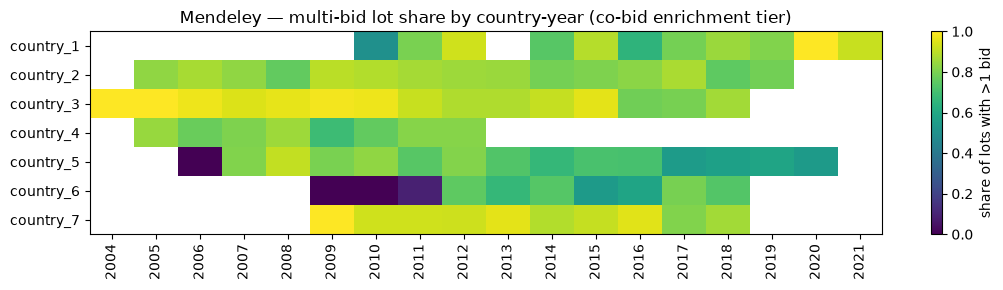

In [6]:
import matplotlib.pyplot as plt
import numpy as np
pivot = coverage.pivot(values="share_multibid", index="country",
                       on="tender_year").sort("country")
years = sorted(int(c) for c in pivot.columns if c != "country")
mat = np.array([[(pivot[str(y)][i] if pivot[str(y)][i] is not None else np.nan)
                 for y in years] for i in range(pivot.height)], dtype=float)
fig, ax = plt.subplots(figsize=(11, 3))
im = ax.imshow(mat, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(years)), years, rotation=90)
ax.set_yticks(range(pivot.height), pivot["country"].to_list())
fig.colorbar(im, label="share of lots with >1 bid")
ax.set_title("Mendeley — multi-bid lot share by country-year (co-bid enrichment tier)")
plt.tight_layout(); plt.show()

In [7]:
summary()


=== VERIFICATION SUMMARY ===
PASS  distinct confirmed cartel cases (statement: 73): expected=73 actual=73
1/1 checks passed


**Conclusions for §4.2.** No losing-bidder identities anywhere in this dataset ⇒ the **award-network-first rule stands**; co-bid *identity* graphs are not constructible from Mendeley alone. `lot_bidscount`/`singleb_avg` support bid-count screens per country-year where non-null. García Rodríguez (notebook 04) carries the full bid-level co-bid analysis instead.